## Objective
The goal of this project is to build an intelligent fraud detection system capable of identifying fraudulent credit card transactions in a highly imbalanced dataset.

## Dataset Information
- Total Transactions: 284,807
- Fraud Transactions: 492
- Features: 30 anonymized PCA features + Amount + Time
- Target Variable: Class

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
from google.colab import files

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 131MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [4]:
df = pd.read_csv('/content/creditcard.csv')

# Exploratory Data Analysis (EDA)

In this section, we analyze:
- Class imbalance
- Transaction amount patterns
- Correlation between features and fraud
- Duplicate records
- Transaction timing patterns

In [5]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

(284807, 31)

In [6]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [7]:
fraud = df[df['Class'] == 1]
valid = df[df['Class'] == 0]
outlier_fraction = len(fraud)/float(len(valid))
print(outlier_fraction)
print('Fraud Cases: {}'.format(len(fraud)))
print('Valid Cases: {}'.format(len(valid)))

0.0017304750013189597
Fraud Cases: 492
Valid Cases: 284315


In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
fraud.Amount.describe()


,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [10]:
valid.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [11]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


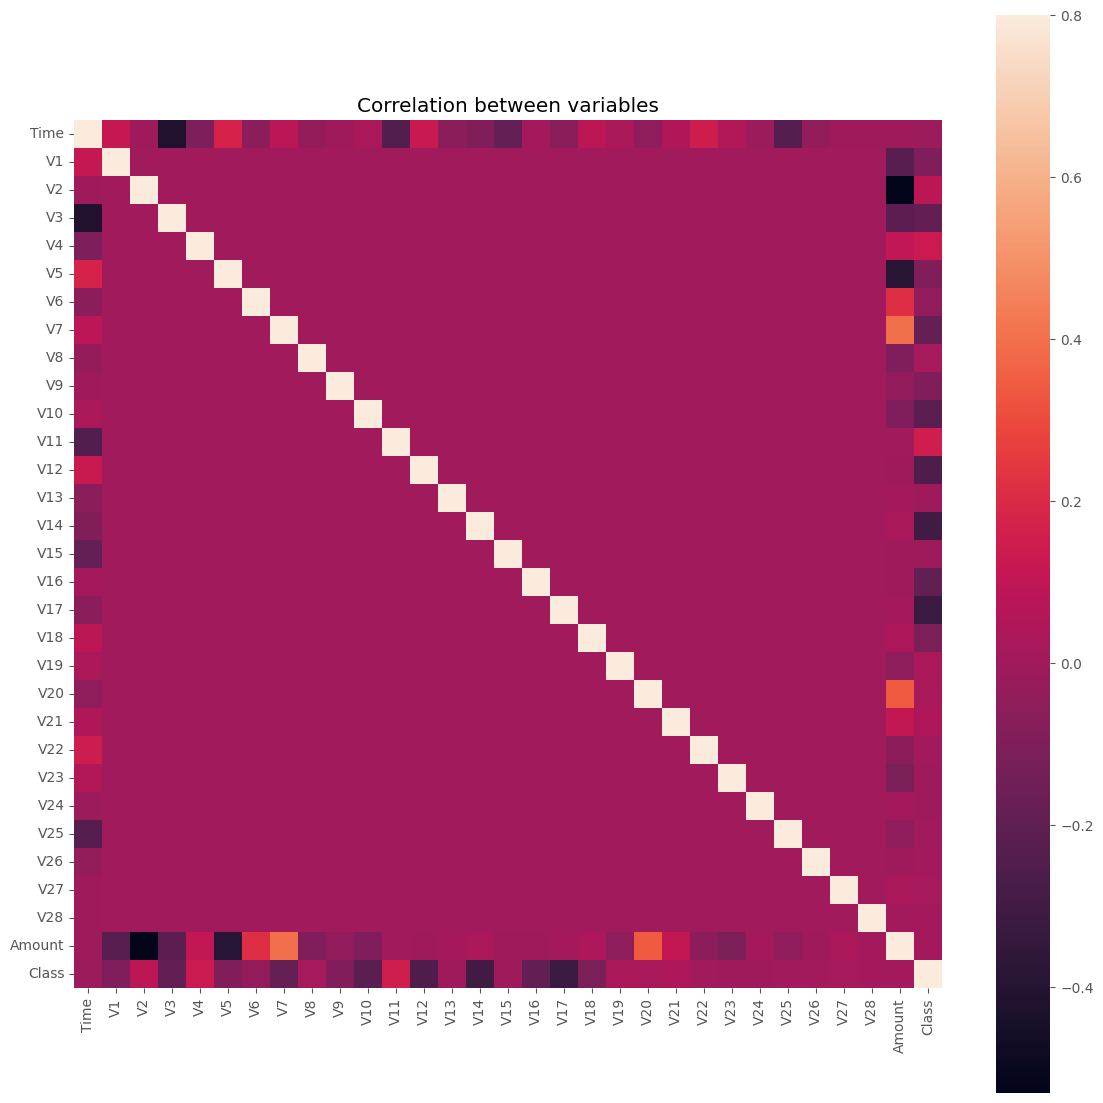

In [12]:
corr = df.corr()
fig = plt.figure(figsize = (14,14))
sns.heatmap( corr, vmax = .8, square = True)
plt.title('Correlation between variables')
plt.show()

In [13]:
cor = df.corr(numeric_only=True)['Class'].sort_values()

In [14]:
cor.head(10)

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


In [15]:
cor.tail(10)

,Class
V28,0.009536
V27,0.017580
V8,0.019875
V20,0.020090
V19,0.034783
V21,0.040413
V2,0.091289
V4,0.133447
V11,0.154876
Class,1.000000


In [16]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Transaction Time Distribution

Understanding how transactions are distributed across time.

<Axes: title={'center': 'Time Distributions of the Dataset'}, xlabel='Time', ylabel='Density'>

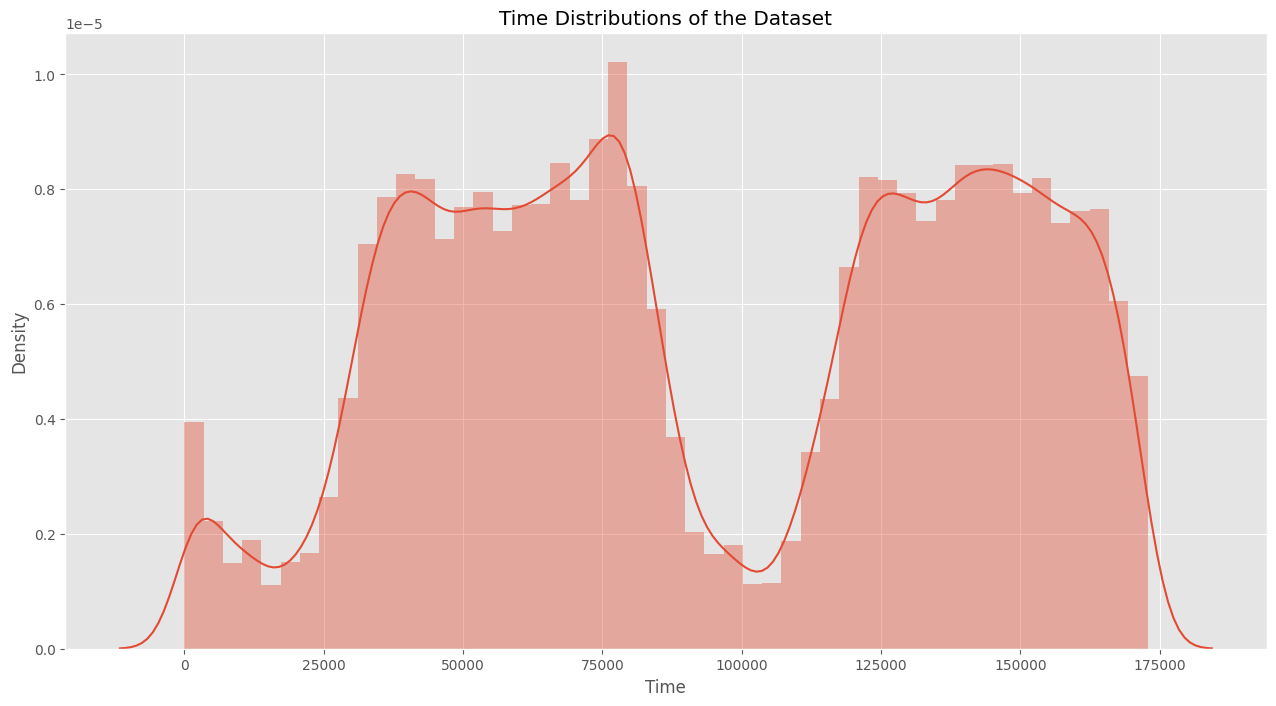

In [17]:
plt.figure(figsize=(15.5, 8))
plt.title('Time Distributions of the Dataset')
sns.distplot(df.Time)

## Class Distribution

The dataset is extremely imbalanced, making accuracy an unreliable evaluation metric.

Text(0.5, 0, 'Class (0:valid, 1:fraud)')

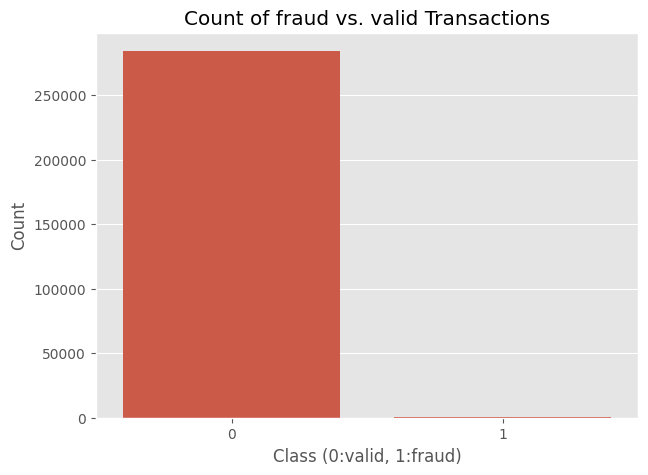

In [18]:
plt.figure(figsize=(7,5))
class_counts = df['Class'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Count of fraud vs. valid Transactions')
plt.ylabel('Count')
plt.xlabel('Class (0:valid, 1:fraud)')

## Duplicate Transaction Analysis

Duplicate transactions may bias the model and artificially inflate performance.

Therefore duplicates are identified and removed before modeling.

In [19]:
duplicates = df[df.duplicated()]
duplicates['Class'].value_counts()

,count
Class,
0,1062
1,19


In [20]:
before_rows = len(df)

df = df.drop_duplicates()

after_rows = len(df)

print(before_rows)
print(after_rows)

284807
283726


In [21]:
df.shape


(283726, 31)

In [22]:
df['Class'].value_counts()

,count
Class,
0,283253
1,473


In [23]:
df['Hour'] = (df['Time']//3600)%24
df.groupby('Hour')['Class'].sum()

,Class
Hour,
0.0,6
1.0,10
2.0,48
3.0,17
4.0,23
5.0,11
6.0,9
7.0,23
8.0,9


In [24]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0


In [25]:
X = df.drop('Class', axis = 1)
y = df['Class']

In [26]:
from collections import Counter
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SVMSMOTE
from lightgbm import LGBMClassifier
from sklearn import metrics
from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42 , stratify= y)

# Model Building

We start with Logistic Regression as a baseline model and then compare advanced techniques for handling class imbalance.

Logistic Regression is used as the first benchmark model due to its simplicity and interpretability.

In [28]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train[['Time', 'Amount']]= scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

In [29]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [31]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(
    roc_auc_score(
        y_test,
        y_prob
    )
)

[[56641    10]
 [   40    55]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

0.9507538771555109


## Fraud Probability Analysis

Analyzing predicted probabilities for fraudulent transactions to understand model confidence.

In [32]:
fraud_probs = y_prob[y_test == 1]
pd.Series(fraud_probs).describe()

,0
count,95.000000
mean,0.583122
std,0.426956
min,0.000024
25%,0.084351
50%,0.754940
75%,0.994951
max,1.000000


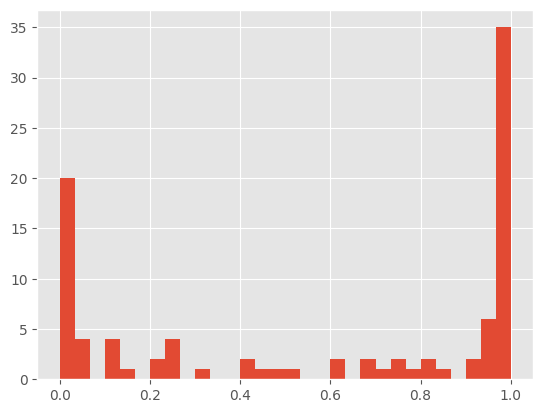

In [33]:
plt.hist(fraud_probs, bins=30)
plt.show()

## Threshold Optimization

Instead of using the default threshold of 0.5, different thresholds are tested to improve fraud recall.

In [34]:
y_pred_03 = (y_prob >= 0.3).astype(int)

In [35]:
classification_report(
    y_test,
    y_pred_03
)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00     56651\n           1       0.83      0.63      0.72        95\n\n    accuracy                           1.00     56746\n   macro avg       0.92      0.82      0.86     56746\nweighted avg       1.00      1.00      1.00     56746\n'

well we can clearly see ki recall increase from 58 to 63, so hum tuning or karenge and best hyperparameter ko finalize karenge


In [36]:
for t in [0.1,0.2,0.3,0.4,0.5]:

    y_pred_t = (y_prob >= t).astype(int)

    print(f"\nThreshold={t}")

    print(
        classification_report(
            y_test,
            y_pred_t
        )
    )


Threshold=0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.75      0.79        95

    accuracy                           1.00     56746
   macro avg       0.92      0.87      0.90     56746
weighted avg       1.00      1.00      1.00     56746


Threshold=0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.69      0.76        95

    accuracy                           1.00     56746
   macro avg       0.92      0.85      0.88     56746
weighted avg       1.00      1.00      1.00     56746


Threshold=0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.63      0.72        95

    accuracy                           1.00     56746
   macro avg       0.92      0.82      0.86     56746
weighted avg       1.00      

### Observation

Lowering the classification threshold increases recall from 58% to 75%, allowing the model to detect more fraudulent transactions.

# Handling Class Imbalance using SMOTE

SMOTE generates synthetic minority class samples to balance the training dataset.

In [37]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [38]:
y_train_sm.value_counts()

,count
Class,
0,226602
1,226602


In [39]:
model_sm = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_sm.fit(X_train_sm, y_train_sm)

LogisticRegression(max_iter=1000, random_state=42)

In [40]:
y_prob_sm = model_sm.predict_proba(X_test)[:,1]

y_pred_sm = model_sm.predict(X_test)

print(classification_report(
    y_test,
    y_pred_sm
))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [41]:
cm = confusion_matrix(y_test,y_pred_sm)

print(cm)

[[55194  1457]
 [   12    83]]


### Observation

Recall improved from 75% to 87%.

However, the number of false positives increased significantly.

In [42]:
y_prob_sm = model_sm.predict_proba(X_test)[:,1]

for t in [0.5,0.6,0.7,0.8,0.9]:

    y_pred_t = (y_prob_sm >= t).astype(int)

    print(f"\nThreshold={t}")

    print(classification_report(y_test,y_pred_t))


Threshold=0.5
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


Threshold=0.6
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.07      0.87      0.13        95

    accuracy                           0.98     56746
   macro avg       0.54      0.93      0.56     56746
weighted avg       1.00      0.98      0.99     56746


Threshold=0.7
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.10      0.87      0.17        95

    accuracy                           0.99     56746
   macro avg       0.55      0.93      0.58     56746
weighted avg       1.00      

### Business Impact

Although more frauds are detected, the excessive false positives may cause unnecessary transaction blocks and poor customer experience.

# Handling Class Imbalance using ADASYN

ADASYN focuses on generating synthetic samples for difficult minority-class observations.

In [43]:
adasyn = ADASYN(random_state=42)

X_train_ada, y_train_ada = adasyn.fit_resample(
    X_train,
    y_train
)

print(y_train_ada.value_counts())

Class
1    226638
0    226602
Name: count, dtype: int64


In [44]:
model_ada = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_ada.fit(
    X_train_ada,
    y_train_ada
)

LogisticRegression(max_iter=1000, random_state=42)

In [45]:
y_prob_ada = model_ada.predict_proba(X_test)[:,1]

y_pred_ada = model_ada.predict(X_test)

print(classification_report(
    y_test,
    y_pred_ada
))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     56651
           1       0.02      0.89      0.04        95

    accuracy                           0.92     56746
   macro avg       0.51      0.91      0.50     56746
weighted avg       1.00      0.92      0.96     56746



### Observation

ADASYN achieved slightly higher recall than SMOTE.

However, precision remained extremely low, making it unsuitable for production deployment.

# Advanced Model: XGBoost

XGBoost is selected because of its ability to handle non-linear relationships and imbalanced classification problems effectively.

In [46]:
scale_pos_weight = (
    len(y_train[y_train==0]) /
    len(y_train[y_train==1])
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [48]:

print(confusion_matrix(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))
print(roc_auc_score(y_test,y_prob_xgb))


[[56602    49]
 [   19    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.61      0.80      0.69        95

    accuracy                           1.00     56746
   macro avg       0.80      0.90      0.85     56746
weighted avg       1.00      1.00      1.00     56746

0.9778758028148339


### Observation

XGBoost achieved the best balance between fraud detection and false positive reduction.

Compared with SMOTE and ADASYN, it significantly reduced false alarms while maintaining strong recall.

# Model Comparison

The following table summarizes the performance of all approaches tested during the project.

| Model             | Precision | Recall   | F1       | ROC-AUC   |
| ----------------- | --------- | -------- | -------- | --------- |
| Logistic (0.5)    | **0.85**  | 0.58     | 0.69     | 0.95      |
| Logistic (0.1)    | **0.85**  | 0.75     | **0.79** | 0.95      |
| SMOTE + Logistic  | 0.05      | **0.87** | 0.10     | -         |
| ADASYN + Logistic | 0.02      | **0.89** | 0.04     | -         |
| XGBoost           | 0.61      | **0.80** | 0.69     | **0.978** |


Logistic Regression

Business-friendly baseline.

# Explainable AI using SHAP

SHAP values are used to understand how each feature contributes to fraud predictions.

In [49]:
!pip install shap

In [50]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

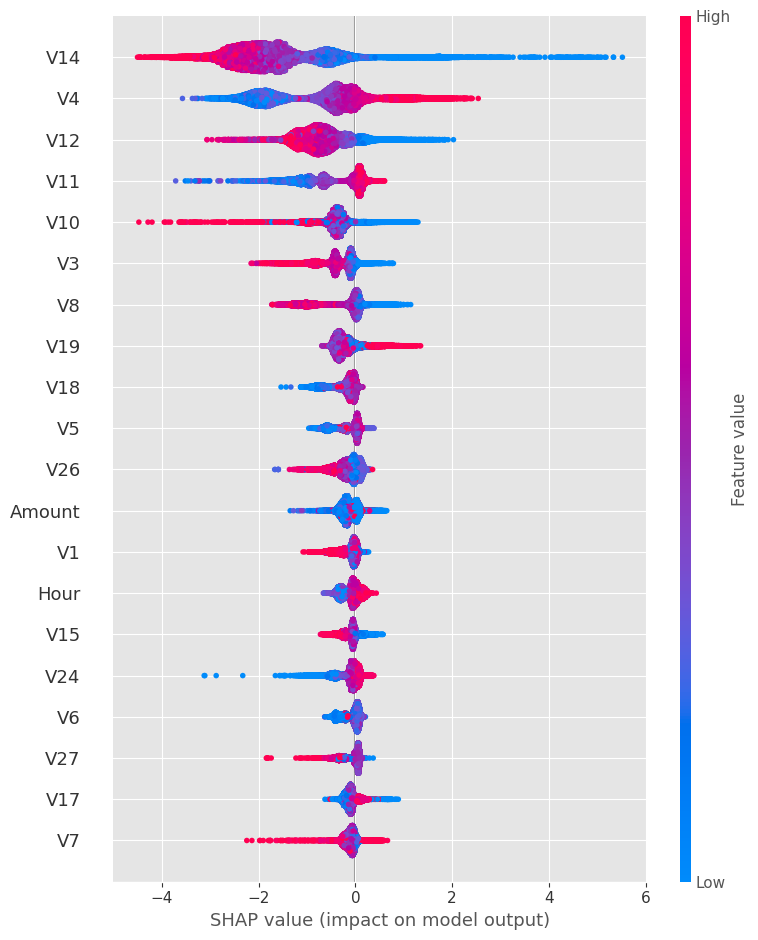

In [51]:
shap.summary_plot(
    shap_values,
    X_test
)

## SHAP Insights

Top Fraud Drivers:

- V14
- V4
- V12
- V11
- V10
- V3
- V8

Blue points indicate low feature values.

Red points indicate high feature values.

| Correlation Top Features | SHAP Top Features |
| ------------------------ | ----------------- |
| V17                      | V14               |
| V14                      | V4                |
| V12                      | V12               |
| V10                      | V11               |
| V16                      | V10               |


### Business Insight

Transaction amount is not among the strongest fraud predictors.

Fraudulent behavior is better characterized by transaction patterns rather than transaction size alone.

In [52]:
risk_prob = xgb.predict_proba(X_test)[:,1]
risk_score = (risk_prob * 100).round(2)

In [53]:
def risk_category(score):

    if score < 30:
        return "Low"

    elif score < 70:
        return "Medium"

    return "High"

In [54]:
risk_score

array([0.02, 0.12, 0.45, ..., 0.42, 0.47, 0.03], dtype=float32)

In [55]:
results = X_test.copy()

results["Actual"] = y_test.values

results["Fraud_Probability"] = risk_prob

results["Risk_Score"] = risk_score

results["Risk_Category"] = (
    results["Risk_Score"]
    .apply(risk_category)
)

results.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Hour,Actual,Fraud_Probability,Risk_Score,Risk_Category
86568,-0.276378,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,0.598550,0.491409,0.002989,0.001782,-0.146619,17.0,0,0.000249,0.02,Low
251557,0.829134,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.710906,-0.234510,0.379640,0.261351,-0.279102,19.0,0,0.001183,0.12,Low
20232,-0.633616,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,-0.155456,-0.062383,0.007777,0.113900,0.958980,8.0,0,0.004463,0.45,Low
68952,-0.371382,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,0.238538,-0.289454,0.038214,0.058407,2.853659,14.0,0,0.001163,0.12,Low
191852,0.524103,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,0.111522,0.642944,-0.036998,-0.043404,-0.286447,11.0,0,0.005373,0.54,Low


| Model          | Precision | Recall | F1   | ROC   |
| -------------- | --------- | ------ | ---- | ----- |
| Logistic       | 0.85      | 0.58   | 0.69 | 0.95  |
| Logistic Tuned | 0.85      | 0.75   | 0.79 | 0.95  |
| SMOTE          | 0.05      | 0.87   | 0.10 | -     |
| ADASYN         | 0.02      | 0.89   | 0.04 | -     |
| XGBoost        | 0.61      | 0.80   | 0.69 | 0.978 |


In [56]:
results['Prediction'] = (
    results['Fraud_Probability'] >= 0.5
).astype(int)

In [57]:
def generate_alert(score):

    if score >= 90:
        return "Critical"

    elif score >= 70:
        return "High"

    elif score >= 30:
        return "Medium"

    return "Low"

In [58]:
results['Alert_Level'] = (
    results['Risk_Score']
    .apply(generate_alert)
)

In [59]:
results.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V27,V28,Amount,Hour,Actual,Fraud_Probability,Risk_Score,Risk_Category,Prediction,Alert_Level
86568,-0.276378,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,0.002989,0.001782,-0.146619,17.0,0,0.000249,0.02,Low,0,Low
251557,0.829134,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,0.379640,0.261351,-0.279102,19.0,0,0.001183,0.12,Low,0,Low
20232,-0.633616,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,0.007777,0.113900,0.958980,8.0,0,0.004463,0.45,Low,0,Low
68952,-0.371382,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,0.038214,0.058407,2.853659,14.0,0,0.001163,0.12,Low,0,Low
191852,0.524103,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.036998,-0.043404,-0.286447,11.0,0,0.005373,0.54,Low,0,Low


In [62]:
results.shape

(56746, 37)

In [60]:
results["Risk_Category"].value_counts()

,count
Risk_Category,
Low,56577
High,95
Medium,74


In [63]:
results["Original_Amount"] = df.loc[X_test.index,"Amount"]

In [64]:
results.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V28,Amount,Hour,Actual,Fraud_Probability,Risk_Score,Risk_Category,Prediction,Alert_Level,Original_Amount
86568,-0.276378,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,0.001782,-0.146619,17.0,0,0.000249,0.02,Low,0,Low,11.50
251557,0.829134,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,0.261351,-0.279102,19.0,0,0.001183,0.12,Low,0,Low,1.94
20232,-0.633616,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,0.113900,0.958980,8.0,0,0.004463,0.45,Low,0,Low,91.28
68952,-0.371382,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,0.058407,2.853659,14.0,0,0.001163,0.12,Low,0,Low,228.00
191852,0.524103,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.043404,-0.286447,11.0,0,0.005373,0.54,Low,0,Low,1.41


In [65]:
results.to_csv(
    "fraud_monitoring_results.csv",
    index=False
)

In [66]:
files.download('fraud_monitoring_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

Key Findings:

- Logistic Regression provided a strong baseline model.
- Threshold tuning improved fraud recall significantly.
- SMOTE and ADASYN improved recall but generated excessive false positives.
- XGBoost achieved the best balance between precision and recall.
- SHAP improved model interpretability and explained fraud-driving factors.
- A fraud risk scoring engine was developed for business monitoring and dashboard reporting.

Final Model:
XGBoost + Explainable AI (SHAP) + Risk Scoring Framework